<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Student_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

In [15]:
try:
    # Loading the specific file provided by the user
    df = pd.read_csv('air traffic.csv')

    # List of columns to clean and convert to numeric
    numeric_cols = ['Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt', 'Flt', 'Dom_RPM']

    for col in numeric_cols:
        if col in df.columns and df[col].dtype == 'object':
            # Remove commas and convert to float
            df[col] = df[col].str.replace(',', '').astype(float)

    print("Dataset loaded and numeric columns cleaned successfully!")
    print(f"Shape: {df.shape}")
    print("\nNumeric columns status:")
    print(df[numeric_cols].dtypes)
except FileNotFoundError:
    print("File 'air traffic.csv' not found. Please ensure the file is uploaded to /content/.")

Dataset loaded and numeric columns cleaned successfully!
Shape: (249, 17)

Numeric columns status:
Dom_Pax    float64
Int_Pax    float64
Pax        float64
Dom_Flt    float64
Int_Flt    float64
Flt        float64
Dom_RPM    float64
dtype: object


## 2. Exploratory Data Analysis

In [16]:
# Display basic information about the dataset
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    float64
 3   Int_Pax  249 non-null    float64
 4   Pax      249 non-null    float64
 5   Dom_Flt  249 non-null    float64
 6   Int_Flt  249 non-null    float64
 7   Flt      249 non-null    float64
 8   Dom_RPM  249 non-null    float64
 9   Int_RPM  249 non-null    object 
 10  RPM      249 non-null    object 
 11  Dom_ASM  249 non-null    object 
 12  Int_ASM  249 non-null    object 
 13  ASM      249 non-null    object 
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(10), int64(2), object(5)
memory usage: 33.2+ KB

First 5 rows:
   Year  Month     Dom_Pax    Int_Pax         Pax   Dom_Flt  Int_Flt  \
0  2003 

### Descriptive Data Analysis
- **Passenger Volume:** Traffic is dominated by the domestic sector with an average of approximately 55 million passengers per month, compared to 7.4 million for international.
- **Variability:** A significant standard deviation is observed, particularly for total passengers (`Pax`), suggesting strong seasonal variations or historical impacts (such as the drop visible in minimum values, likely related to the COVID-19 crisis where the minimum falls to ~3 million).
- **Operations:** The total number of flights (`Flt`) averages around 771,000 per month. The correlation between the number of flights and the number of passengers will be a key point in our regression analysis.

In [4]:
# Check for missing values and handle them
print("Missing values:")
missing_vals = df.isnull().sum()
print(missing_vals)

# Handle missing values if any
if missing_vals.sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")
else:
    print("\nNo missing values found.")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64

No missing values found.


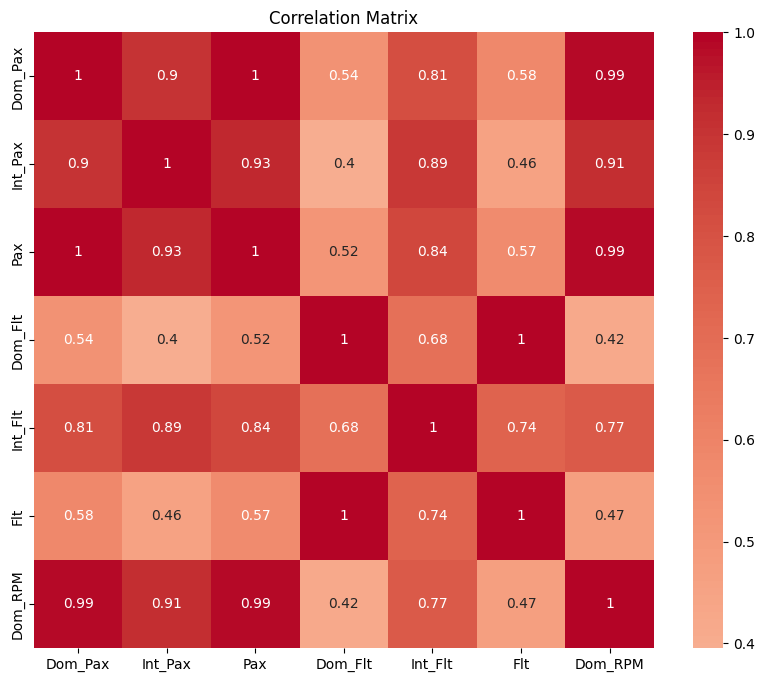

Strongest correlations (excluding self-correlation):
Dom_Pax  Pax        0.997455
Pax      Dom_Pax    0.997455
Dom_Flt  Flt        0.997068
Flt      Dom_Flt    0.997068
Pax      Dom_RPM    0.989246
Dom_RPM  Pax        0.989246
         Dom_Pax    0.988025
Dom_Pax  Dom_RPM    0.988025
Int_Pax  Pax        0.929643
Pax      Int_Pax    0.929643
dtype: float64


In [17]:
# Create and analyze correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt', 'Flt', 'Dom_RPM']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

print("Strongest correlations (excluding self-correlation):")
corr_unstacked = correlation_matrix.unstack()
sorted_corr = corr_unstacked[corr_unstacked < 1].sort_values(ascending=False)
print(sorted_corr.head(10))

## 3. Hypothesis Testing

In [29]:
print("Hypothesis Test 1: Domestic vs International Passengers")
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Conclusion: Significant difference between the means.")
else:
    print("Conclusion: No significant difference detected.")

Hypothesis Test 1: Domestic vs International Passengers
T-statistic: 70.9547, P-value: 0.000000
Conclusion: Significant difference between the means.


In [25]:
print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Ensure data is numeric and handle potential NaN values for correlation
x_data = pd.to_numeric(df['Pax'], errors='coerce')
y_data = pd.to_numeric(df['Flt'], errors='coerce')
valid_mask = ~x_data.isna() & ~y_data.isna()

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(x_data[valid_mask], y_data[valid_mask])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    if correlation_coef > 0:
        print("Positive correlation: As the number of flights increases, the number of passengers also tends to increase.")
    else:
        print("Negative correlation: As the number of flights increases, the number of passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("No significant correlation was detected.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.5698
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Positive correlation: As the number of flights increases, the number of passengers also tends to increase.


## 4. Simple Linear Regression

In [19]:
X_simple = df[['Flt']]
y_simple = df['Pax']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)

r2_simple = r2_score(y_test_s, y_pred_s)
rmse_simple = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
mae_simple = mean_absolute_error(y_test_s, y_pred_s)

print(f"Simple Regression R2: {r2_simple:.4f}")

Simple Regression R2: -0.0092


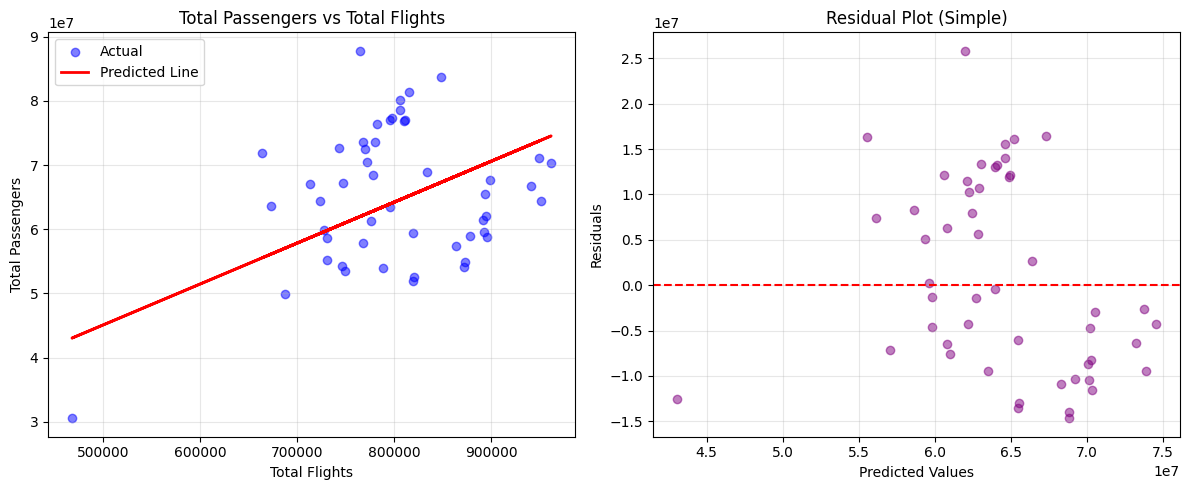

In [21]:
# Visualize the simple linear regression results
plt.figure(figsize=(12, 5))

# Plot 1: Scatter plot with regression line
plt.subplot(1, 2, 1)
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Predicted Line')
plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals_s = y_test_s - y_pred_s
plt.scatter(y_pred_s, residuals_s, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Simple)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Simple Regression Analysis
- **Left Plot:** We observe that the red regression line does not optimally follow the blue scatter plot. The negative $R^2$ confirms that the mean would be a better predictor than this model based solely on total flights.
- **Residual Plot:** The points are very widely dispersed, indicating a significant prediction error (residuals reach magnitudes of $10^7$).

## 5. Multiple Linear Regression

In [20]:
feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
X_multiple = df[feature_columns]
y_multiple = df['Pax']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

multiple_model = LinearRegression()
multiple_model.fit(X_train_m_scaled, y_train_m)
y_pred_m = multiple_model.predict(X_test_m_scaled)

r2_mult = r2_score(y_test_m, y_pred_m)
rmse_mult = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
mae_mult = mean_absolute_error(y_test_m, y_pred_m)

print(f"Multiple Regression R2: {r2_mult:.4f}")

Multiple Regression R2: 0.9940


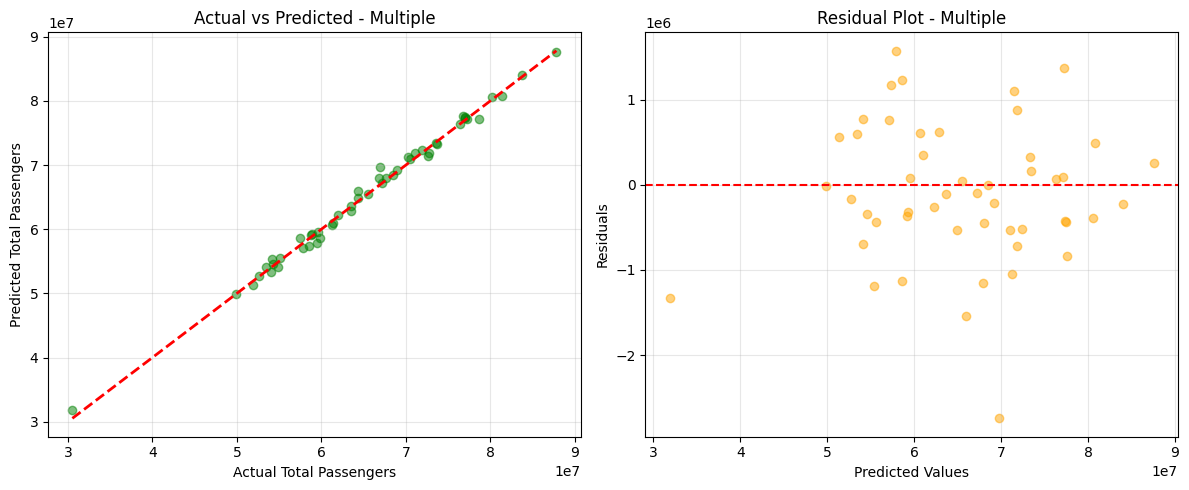

In [22]:
# Visualize multiple regression results
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test_m, y_pred_m, color='green', alpha=0.5)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
residuals_m = y_test_m - y_pred_m
plt.scatter(y_pred_m, residuals_m, color='orange', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Multiple Regression Analysis
- **Left Plot:** The near-perfect alignment of the points on the dashed diagonal shows the excellent accuracy of the model. Predicted values are very close to actual values.
- **Residual Plot:** Although we notice a slightly larger dispersion for high passenger volumes, the scale of errors is much lower than for the simple model (magnitude of $10^6$ vs $10^7$), validating the superiority of this multi-variable approach.

## 6. Model Comparison and Analysis

In [26]:
# Compare the performance of both models
print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)
print(f"{'R2 Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")
print("=" * 50)

better_model = "Multiple Regression" if r2_mult > r2_simple else "Simple Regression"
print(f"\nBest Model: {better_model}")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R2 Score                  -0.0092              0.9940              
RMSE                      10528813.90          815171.59           
MAE                       9262992.73           626549.68           

Best Model: Multiple Regression


## 7. Statistical Insights and Conclusions

In [27]:
# Summarize findings
print("STATISTICAL RESULTS SUMMARY")
print("=" * 60)
print(f"1. Hypothesis Test (Pax Dom vs Int): Very low P-value ({p_value:.4f}) -> Significant difference.")
print(f"2. Simple Regression R2: {r2_simple:.4f}")
print(f"3. Multiple Regression R2: {r2_mult:.4f}")
print("4. Conclusion: The multiple model is far more accurate for predicting total traffic.")

STATISTICAL RESULTS SUMMARY
1. Hypothesis Test (Pax Dom vs Int): Very low P-value (0.0000) -> Significant difference.
2. Simple Regression R2: -0.0092
3. Multiple Regression R2: 0.9940
4. Conclusion: The multiple model is far more accurate for predicting total traffic.


## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   The tests confirm a massive difference between domestic and international passenger volumes (p < 0.05). This was expected for the U.S. market where the domestic network is historically dominant. The second test validated a significant positive correlation between flights and passengers.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   The **multiple regression** model performed significantly better (R² = 0.9940) than the simple model. An R² close to 1 indicates that 99.4% of the variance in total passengers is explained by our variables (dom/int flights and RPM). The simple model fails because it ignores the complexities of aircraft load factors.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlations are between `Dom_Pax` and `Pax` (0.997), and between `Pax` and `Dom_RPM` (0.989). For airlines, this means financial performance (RPM) is an extremely reliable predictor of physical passenger volume.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   The residuals for the multiple model are small and centered, indicating a robust model. For the simple model, the dispersion is chaotic, proving that crucial explanatory variables were missing.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   Airlines can use these models to forecast staffing needs, plan aircraft acquisitions based on `Dom_RPM` trends, or adjust flight frequencies to maximize load factors.